In [1]:
#from ema_workbench import load_results

#experiments, outcomes = load_results('ema_resultsprobstate3.tar.gz')

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from openpyxl.styles.builtins import output
from ema_workbench import (
    Model,
    Policy,
    ema_logging,
    SequentialEvaluator,
    MultiprocessingEvaluator,
)
from dike_model_function import DikeNetwork  # @UnresolvedImport
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

In [2]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(3)

In [3]:
# enlisting uncertainties, their types (RealParameter/IntegerParameter/CategoricalParameter), lower boundary, and upper boundary
import copy

for unc in dike_model.uncertainties:
    print(repr(unc))

uncertainties = copy.deepcopy(dike_model.uncertainties)

CategoricalParameter('discount rate 0', [0, 1, 2, 3])
CategoricalParameter('discount rate 1', [0, 1, 2, 3])
CategoricalParameter('discount rate 2', [0, 1, 2, 3])
IntegerParameter('A.0_ID flood wave shape', 0, 132, resolution=None, default=None, variable_name=['A.0_ID flood wave shape'], pff=False)
RealParameter('A.1_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.1_Bmax'], pff=False)
RealParameter('A.1_pfail', 0, 1, resolution=None, default=None, variable_name=['A.1_pfail'], pff=False)
CategoricalParameter('A.1_Brate', [0, 1, 2])
RealParameter('A.2_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.2_Bmax'], pff=False)
RealParameter('A.2_pfail', 0, 1, resolution=None, default=None, variable_name=['A.2_pfail'], pff=False)
CategoricalParameter('A.2_Brate', [0, 1, 2])
RealParameter('A.3_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.3_Bmax'], pff=False)
RealParameter('A.3_pfail', 0, 1, resolution=None, default=None, variable_name=['A.3_pfai

In [4]:
# enlisting policy levers, their types (RealParameter/IntegerParameter), lower boundary, and upper boundary
for policy in dike_model.levers:
    print(repr(policy))

levers = copy.deepcopy(dike_model.levers)

IntegerParameter('0_RfR 0', 0, 1, resolution=None, default=None, variable_name=['0_RfR 0'], pff=False)
IntegerParameter('0_RfR 1', 0, 1, resolution=None, default=None, variable_name=['0_RfR 1'], pff=False)
IntegerParameter('0_RfR 2', 0, 1, resolution=None, default=None, variable_name=['0_RfR 2'], pff=False)
IntegerParameter('1_RfR 0', 0, 1, resolution=None, default=None, variable_name=['1_RfR 0'], pff=False)
IntegerParameter('1_RfR 1', 0, 1, resolution=None, default=None, variable_name=['1_RfR 1'], pff=False)
IntegerParameter('1_RfR 2', 0, 1, resolution=None, default=None, variable_name=['1_RfR 2'], pff=False)
IntegerParameter('2_RfR 0', 0, 1, resolution=None, default=None, variable_name=['2_RfR 0'], pff=False)
IntegerParameter('2_RfR 1', 0, 1, resolution=None, default=None, variable_name=['2_RfR 1'], pff=False)
IntegerParameter('2_RfR 2', 0, 1, resolution=None, default=None, variable_name=['2_RfR 2'], pff=False)
IntegerParameter('3_RfR 0', 0, 1, resolution=None, default=None, variable

In [5]:
# enlisting outcomes
for outcome in dike_model.outcomes:
    print(repr(outcome))

ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x1392f9580>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x1392f9580>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x1392f9580>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x1392f9580>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x1392f9580>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x1392f9580>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Damage', 'A.4_Dike Investment Costs'), functio

In [6]:
# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=100, policies=1)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 100 scenarios * 1 policies * 1 model(s) = 100 experiments
100%|████████████████████████████████████████| 100/100 [00:03<00:00, 33.12it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [7]:
experiments, outcomes = results

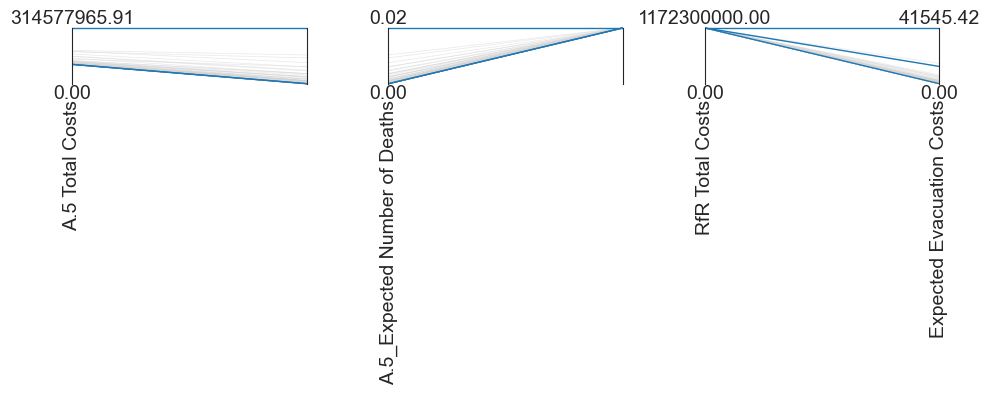

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ema_workbench.analysis import parcoords

# Combine all outcomes into a single DataFrame
all_data = pd.DataFrame({k: v for k, v in outcomes.items()})

# Focus only on selected outcomes
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]
all_data = all_data[selected_outcomes]

# Get indices of rows with min and max values across outcomes
indices = pd.concat([all_data.idxmax(), all_data.idxmin()]).unique()

# Create axis limits and force min to 0
limits = parcoords.get_limits(all_data)
limits.loc[0, selected_outcomes] = 0

# Initialize parallel coordinates plot
axes = parcoords.ParallelAxes(limits)

# Plot all lines in grey with transparency
axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)

# Highlight rows with extreme values
axes.plot(all_data.loc[indices], color=sns.color_palette()[0], lw=1)

# Final layout
fig = plt.gcf()
fig.set_size_inches((10, 4))  # wider if needed
plt.tight_layout()
plt.show()


In [9]:
print(all_data.idxmax())
print(all_data.idxmin())

A.5 Total Costs                  22
A.5_Expected Number of Deaths    22
RfR Total Costs                   0
Expected Evacuation Costs         6
dtype: int64
A.5 Total Costs                  0
A.5_Expected Number of Deaths    0
RfR Total Costs                  0
Expected Evacuation Costs        0
dtype: int64


In [10]:
# also all we need are the uncertainty columns
#worst case scenario
selected = experiments.loc[[22, 6, 0], ['A.1_Brate',
'A.2_Bmax',
'A.2_pfail',
'A.2_Brate',
'A.3_Bmax',
'A.3_pfail',
'A.3_Brate',
'A.4_Bmax',
'A.4_pfail',
'A.4_Brate',
'A.5_Bmax',
'A.5_pfail',
'A.5_Brate']]
selected

,A.1_Brate,A.2_Bmax,A.2_pfail,A.2_Brate,A.3_Bmax,A.3_pfail,A.3_Brate,A.4_Bmax,A.4_pfail,A.4_Brate,A.5_Bmax,A.5_pfail,A.5_Brate
22,1.0,235.476727,0.266303,1.5,46.443672,0.731033,1.0,33.383745,0.097081,1.0,94.418439,0.005578,1.0
6,1.0,183.077826,0.236592,1.5,314.614921,0.003603,1.5,171.689129,0.594573,1.5,114.795992,0.302854,1.0
0,1.5,67.210457,0.990939,1.0,186.272277,0.470964,10.0,137.288471,0.407103,10.0,35.264221,0.791180,10.0


In [11]:
#toevoegen aan lijst van scenarios
from ema_workbench import Scenario

scenarios = [Scenario(f"{index}", **row) for index, row in selected.iterrows()]

In [12]:
from sklearn import preprocessing
y = outcomes['A.5_Expected Number of Deaths'] < 0.000000001

experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k:v[y] for k,v in outcomes.items()})

# normalize outcomes on unit interval to ensure equal weighting of outcomes
x = outcomes_df.values
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
normalized_outcomes = pd.DataFrame(x_scaled, columns=outcomes_df.columns)

In [13]:
import itertools

n_scen = experiments.loc[y].shape[0]
indices = range(n_scen)
set_size = 4
n_scen
combinations = itertools.combinations(indices, set_size)
combinations = list(combinations)

In [14]:
print(len(combinations))

367290


In [15]:
import random

sampled_combinations = random.sample(combinations, 100000)

In [16]:
from concurrent.futures import ProcessPoolExecutor
import os
import functools
from scipy.spatial.distance import pdist, squareform

# the relevant code is in a .py file to esnure parallization works within the notebook
from assignment_10_scenario_selection import find_maxdiverse_scenarios

# calculate the pairwise distances between the normalized outcomes
distances = squareform(pdist(normalized_outcomes.values))

cores = os.cpu_count()
partial_function = functools.partial(find_maxdiverse_scenarios, distances)

# setup the pool of workers and split the calculations over the set of cores
with ProcessPoolExecutor(max_workers=cores) as executor:
    worker_data = np.array_split(sampled_combinations, cores)
    results = [e for e in executor.map(partial_function, worker_data)]
    results = list(itertools.chain.from_iterable(results))


In [17]:
results.sort(key=lambda entry:entry[0], reverse=True)
most_diverse = results[0]
most_diverse

([np.float64(1.0276067197141574)], array([ 3, 21, 29, 32]))

In [19]:
from ema_workbench import Scenario

selected = experiments.loc[most_diverse[1], ['A.1_Brate',
'A.2_Bmax',
'A.2_pfail',
'A.2_Brate',
'A.3_Bmax',
'A.3_pfail',
'A.3_Brate',
'A.4_Bmax',
'A.4_pfail',
'A.4_Brate',
'A.5_Bmax',
'A.5_pfail',
'A.5_Brate']]
scenarios = [Scenario(f"{index}", **row) for index, row in selected.iterrows()]

for scenario in scenarios:
    print(scenario)

Scenario({'A.1_Brate': np.float64(10.0), 'A.2_Bmax': np.float64(313.0713024278025), 'A.2_pfail': np.float64(0.3396155620585846), 'A.2_Brate': np.float64(10.0), 'A.3_Bmax': np.float64(74.19911574036749), 'A.3_pfail': np.float64(0.8917506998476988), 'A.3_Brate': np.float64(1.5), 'A.4_Bmax': np.float64(77.95284755180339), 'A.4_pfail': np.float64(0.5747295674595974), 'A.4_Brate': np.float64(1.5), 'A.5_Bmax': np.float64(83.5962969520812), 'A.5_pfail': np.float64(0.6021766659747755), 'A.5_Brate': np.float64(1.5)})
Scenario({'A.1_Brate': np.float64(10.0), 'A.2_Bmax': np.float64(296.56896186542946), 'A.2_pfail': np.float64(0.7186875590235604), 'A.2_Brate': np.float64(1.5), 'A.3_Bmax': np.float64(78.0182465546191), 'A.3_pfail': np.float64(0.02596920591586058), 'A.3_Brate': np.float64(1.5), 'A.4_Bmax': np.float64(346.7995259509634), 'A.4_pfail': np.float64(0.210800576578697), 'A.4_Brate': np.float64(1.5), 'A.5_Bmax': np.float64(329.0239258153121), 'A.5_pfail': np.float64(0.40190061368480046), 'A

In [20]:
from ema_workbench import (Model, RealParameter, ScalarOutcome)

In [24]:
from ema_workbench import MultiprocessingEvaluator, ema_logging
from ema_workbench.em_framework.evaluators import BaseEvaluator

from ema_workbench.em_framework.optimization import (ArchiveLogger,
                                                     EpsilonProgress,
                                                     to_problem, epsilon_nondominated)

ema_logging.log_to_stderr(ema_logging.INFO)

def optimize(scenario, nfe, dike_model, epsilons):
    results = []
    convergences = []
    problem = to_problem(dike_model, searchover="levers")

    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }
    scen1 = {}

    for key in dike_model.uncertainties:
        name_split = key.name.split("_")

        if len(name_split) == 1:
            scen1.update({key.name: reference_values[key.name]})

        else:
            scen1.update({key.name: reference_values[name_split[1]]})

    ref_scenario = Scenario("reference", **scen1)

    with MultiprocessingEvaluator(dike_model) as evaluator:
        for i in range(5):
            convergence_metrics = [
                ArchiveLogger(
                    "./archives",
                    [l.name for l in dike_model.levers],
                    [o.name for o in dike_model.outcomes],
                    base_filename=f"MORDM_{scenario.name}_seed_{i}.tar.gz",
                ),
                EpsilonProgress(),
            ]

            result, convergence = evaluator.optimize(nfe=nfe, searchover='levers',
                                         convergence=convergence_metrics,
                                         epsilons=epsilons,
                                         reference=ref_scenario)

            results.append(result)
            convergences.append(convergence)

    # merge the results using a non-dominated sort
    reference_set = epsilon_nondominated(results, epsilons, problem)

    return reference_set, convergences


results = []
for scenario in scenarios:
    epsilons = [0.05,]*len(dike_model.outcomes)

    # note that 100000 nfe is again rather low to ensure proper convergence
    results.append(optimize(scenario, 1e5, dike_model, epsilons))

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] terminating pool


FileExistsError: [Errno 17] File exists: '/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/final assignment/archives/tmp'

In [28]:
import os
import numpy as np
from ema_workbench import (
    Scenario,
    MultiprocessingEvaluator,
    ema_logging,
)
from ema_workbench.em_framework.optimization import (
    ArchiveLogger,
    EpsilonProgress,
    to_problem,
    epsilon_nondominated
)

ema_logging.log_to_stderr(ema_logging.INFO)

# ------------------------------
# Define the optimization function
# ------------------------------
def optimize(scenario, nfe, dike_model, epsilons):
    results = []
    convergences = []
    problem = to_problem(dike_model, searchover="levers")

    # Reference values to build reference scenario
    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }

    # Translate model uncertainties into scenario values
    scen1 = {}
    for key in dike_model.uncertainties:
        name_split = key.name.split("_")
        if len(name_split) == 1:
            scen1[key.name] = reference_values[key.name]
        else:
            scen1[key.name] = reference_values[name_split[1]]

    ref_scenario = Scenario("reference", **scen1)

    # Use a unique folder for each scenario to avoid file conflicts
    archive_dir = f"./archives/scenario_{scenario.name}"
    os.makedirs(archive_dir, exist_ok=True)

    with MultiprocessingEvaluator(dike_model) as evaluator:
        for i in range(5):  # repeat optimization 5 times per scenario
            convergence_metrics = [
                ArchiveLogger(
                    archive_dir,
                    [l.name for l in dike_model.levers],
                    [o.name for o in dike_model.outcomes],
                    base_filename=f"MORDM_{scenario.name}_seed_{i}.tar.gz",
                ),
                EpsilonProgress(),
            ]

            result, convergence = evaluator.optimize(
                nfe=nfe,
                searchover='levers',
                convergence=convergence_metrics,
                epsilons=epsilons,
                reference=ref_scenario,
            )

            results.append(result)
            convergences.append(convergence)

    # Merge and filter non-dominated solutions
    reference_set = epsilon_nondominated(results, epsilons, problem)

    return reference_set, convergences

# ------------------------------
# Run optimization across scenarios
# ------------------------------

results = []

for scenario in scenarios:
    epsilons = [0.05] * len(dike_model.outcomes)
    reference_set, convergences = optimize(scenario, int(100), dike_model, epsilons)
    results.append((scenario.name, reference_set, convergences))


[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 100/100 [00:02<00:00, 36.89it/s]
[MainProcess/INFO] optimization completed, found 82 solutions
100%|████████████████████████████████████████| 100/100 [00:02<00:00, 34.83it/s]
[MainProcess/INFO] optimization completed, found 68 solutions
100%|████████████████████████████████████████| 100/100 [00:02<00:00, 34.38it/s]
[MainProcess/INFO] optimization completed, found 83 solutions
100%|████████████████████████████████████████| 100/100 [00:02<00:00, 35.02it/s]
[MainProcess/INFO] optimization completed, found 67 solutions
100%|████████████████████████████████████████| 100/100 [00:02<00:00, 34.13it/s]
[MainProcess/INFO] optimization completed, found 76 solutions
[MainProcess/INFO] terminating pool


EMAError: Parameter names ['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2'] not found in archive